# Exploration des données — Market Mood Lake

Analyse exploratoire des séquences fenêtrées exportées depuis MongoDB (`data/curated_export/*.npz`), avant l'entraînement du GRU.

Deux jeux de données possibles :
- `market_sequences.npz` : mono-indice (S&P500 seul)
- `market_sequences_xs.npz` / `market_sequences_xs_full.npz` : cross-sectional (plusieurs actions)

Les features stockées sont en unités brutes (non normalisées) : `close`, `log_return`, `rolling_vol_20d`, `rsi_14`, `ma_ratio`, `vix_close`, `fear_greed_score`. La normalisation (z-score) n'intervient qu'au moment de l'entraînement (`src/ml/dataset.py`).

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NPZ_PATH = "../data/curated_export/market_sequences.npz"  # adapter si besoin (ex: market_sequences_xs.npz)

data = np.load(NPZ_PATH, allow_pickle=True)
features = data["features"]   # shape (n_sequences, window_size, n_features)
labels = data["labels"]        # shape (n_sequences,)
dates = data["dates"]          # date de fin de chaque fenêtre
tickers = data["tickers"]      # 'SP500' en mono-indice, ticker réel en cross-sectional

FEATURE_NAMES = ["close", "log_return", "rolling_vol_20d", "rsi_14", "ma_ratio", "vix_close", "fear_greed_score"]

print(f"Nombre de séquences : {len(labels):,}")
print(f"Forme des features : {features.shape}")
print(f"Tickers uniques : {len(set(tickers.tolist()))}")
print(f"Période couverte : {dates.min()} -> {dates.max()}")

Nombre de séquences : 2,837
Forme des features : (2837, 30, 7)
Tickers uniques : 1
Période couverte : 2015-02-17 -> 2026-07-01


## 1. Équilibre des classes (hausse / baisse)

Vérifie la proportion de la classe majoritaire — c'est la baseline triviale à laquelle le GRU est comparé dans `train.py`.

Proportion de labels 'hausse' (1) : 0.5411
Proportion de labels 'baisse' (0) : 0.4589
Baseline (classe majoritaire) : 0.5411


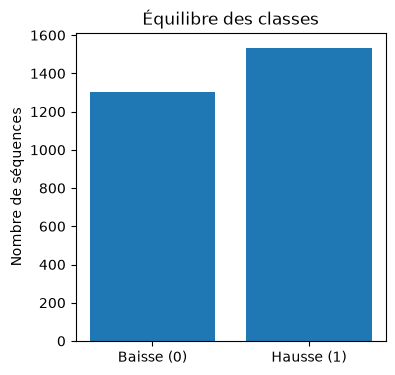

In [6]:
positive_rate = labels.mean()
print(f"Proportion de labels 'hausse' (1) : {positive_rate:.4f}")
print(f"Proportion de labels 'baisse' (0) : {1 - positive_rate:.4f}")
print(f"Baseline (classe majoritaire) : {max(positive_rate, 1 - positive_rate):.4f}")

plt.figure(figsize=(4, 4))
plt.bar(["Baisse (0)", "Hausse (1)"], [ (labels == 0).sum(), (labels == 1).sum() ])
plt.ylabel("Nombre de séquences")
plt.title("Équilibre des classes")
plt.show()

## 2. Évolution du prix de clôture (dernier jour de chaque fenêtre)

En cross-sectional, ce graphe mélange plusieurs tickers : filtrer sur un seul ticker donne une vraie série chronologique.

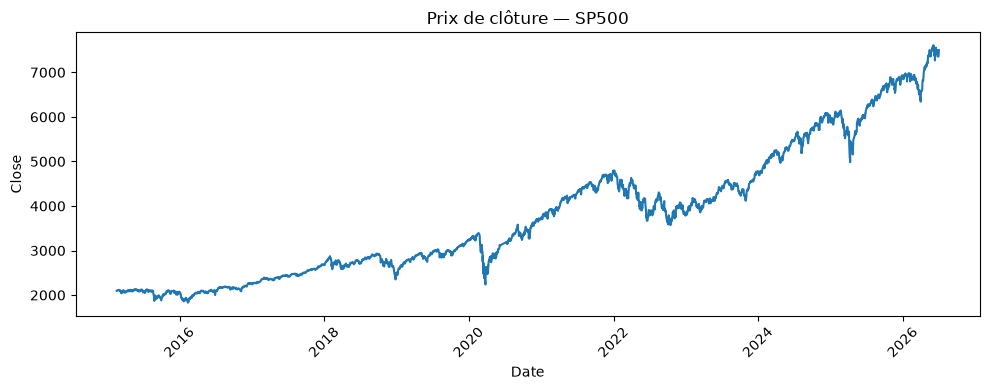

In [7]:
close_idx = FEATURE_NAMES.index("close")
last_close = features[:, -1, close_idx]  # dernier jour de chaque fenêtre

single_ticker = tickers[0]
mask = tickers == single_ticker

plt.figure(figsize=(10, 4))
plt.plot(pd.to_datetime(dates[mask]), last_close[mask])
plt.title(f"Prix de clôture — {single_ticker}")
plt.xlabel("Date")
plt.ylabel("Close")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. VIX vs Fear & Greed Index

Ces deux indicateurs mesurent le sentiment de marché de façons différentes : le VIX est une mesure de volatilité implicite (peur), le Fear & Greed Index est un composite (momentum, volatilité, ratio put/call, etc.). On s'attend à une relation globalement inverse (VIX haut = marché plutôt "fear", donc score bas).

Corrélation VIX / Fear&Greed : -0.499


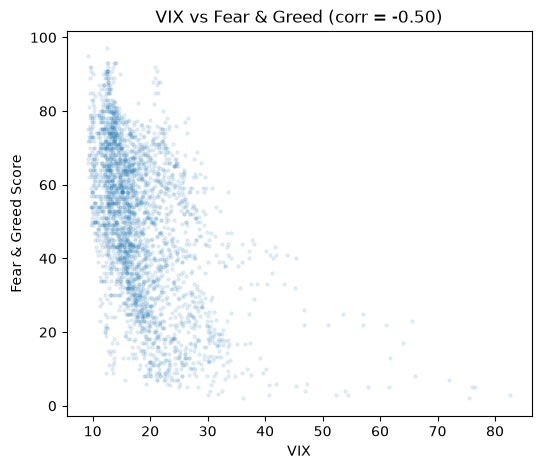

In [8]:
vix_idx = FEATURE_NAMES.index("vix_close")
fg_idx = FEATURE_NAMES.index("fear_greed_score")

last_vix = features[:, -1, vix_idx]
last_fg = features[:, -1, fg_idx]

corr = np.corrcoef(last_vix, last_fg)[0, 1]
print(f"Corrélation VIX / Fear&Greed : {corr:.3f}")

plt.figure(figsize=(6, 5))
plt.scatter(last_vix, last_fg, alpha=0.1, s=5)
plt.xlabel("VIX")
plt.ylabel("Fear & Greed Score")
plt.title(f"VIX vs Fear & Greed (corr = {corr:.2f})")
plt.show()

## 4. Corrélations entre features (dernier jour de chaque fenêtre)

                  close  log_return  rolling_vol_20d  rsi_14  ma_ratio  \
close             1.000       0.027           -0.025   0.097     0.166   
log_return        0.027       1.000            0.012   0.304     0.002   
rolling_vol_20d  -0.025       0.012            1.000  -0.389    -0.688   
rsi_14            0.097       0.304           -0.389   1.000     0.621   
ma_ratio          0.166       0.002           -0.688   0.621     1.000   
vix_close         0.077      -0.173            0.813  -0.546    -0.558   
fear_greed_score -0.023       0.131           -0.428   0.786     0.670   
label             0.016       0.025           -0.008   0.001     0.006   

                  vix_close  fear_greed_score  label  
close                 0.077            -0.023  0.016  
log_return           -0.173             0.131  0.025  
rolling_vol_20d       0.813            -0.428 -0.008  
rsi_14               -0.546             0.786  0.001  
ma_ratio             -0.558             0.670  0.006  
vix

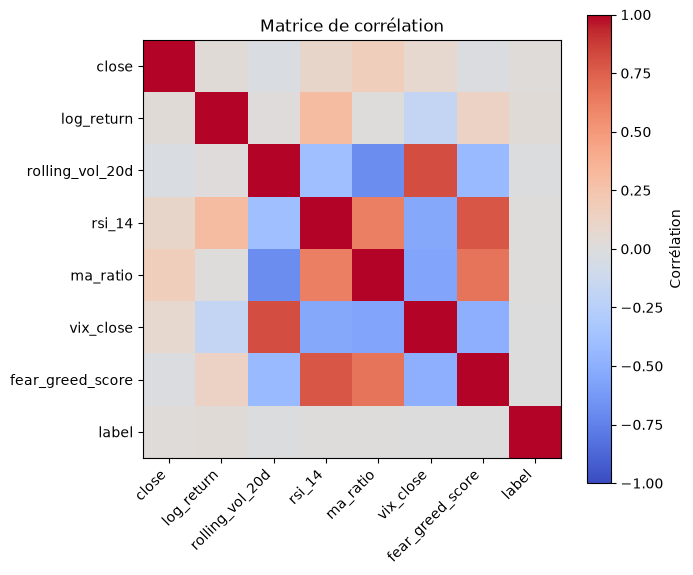

In [9]:
last_day_features = features[:, -1, :]
df_last = pd.DataFrame(last_day_features, columns=FEATURE_NAMES)
df_last["label"] = labels

corr_matrix = df_last.corr()
print(corr_matrix.round(3))

plt.figure(figsize=(7, 6))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Corrélation")
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

## 5. Distribution du RSI et du ratio de moyennes mobiles

Vérifie que les indicateurs techniques sont dans leurs plages attendues (RSI entre 0 et 100).

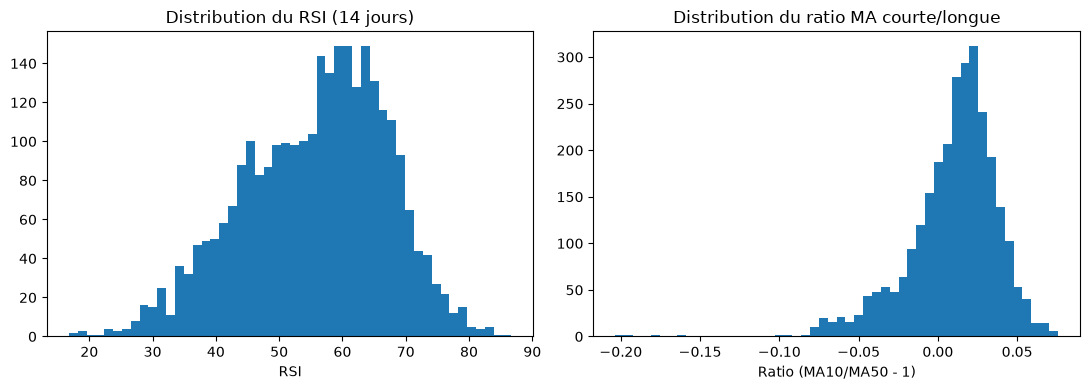

In [10]:
rsi_idx = FEATURE_NAMES.index("rsi_14")
ma_idx = FEATURE_NAMES.index("ma_ratio")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(features[:, -1, rsi_idx], bins=50)
axes[0].set_title("Distribution du RSI (14 jours)")
axes[0].set_xlabel("RSI")

axes[1].hist(features[:, -1, ma_idx], bins=50)
axes[1].set_title("Distribution du ratio MA courte/longue")
axes[1].set_xlabel("Ratio (MA10/MA50 - 1)")

plt.tight_layout()
plt.show()